<a href="https://colab.research.google.com/github/anchietajunior/pdi2026/blob/main/pdi_01_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imagem 1 ----------------------


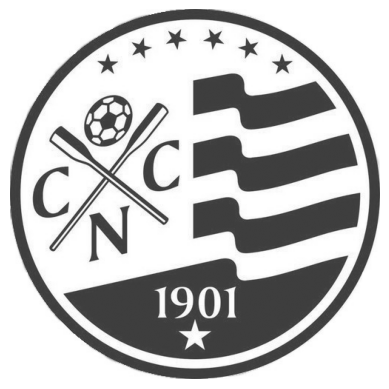

Shape (500, 500)
Redimensionada (com vizinhos) ----------------------


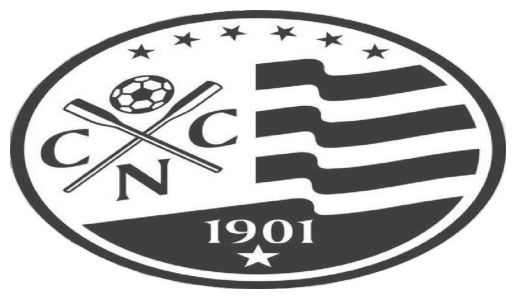

Shape (720, 1280)
Redimensionada (bilinear) ----------------------


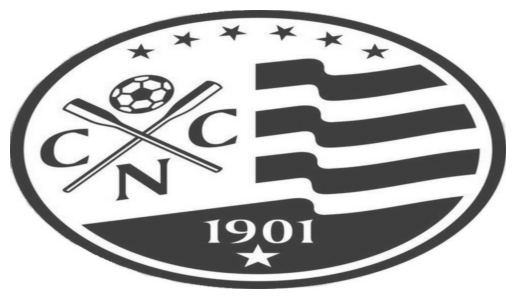

Shape (720, 1280)
----------------------
HIstogramas


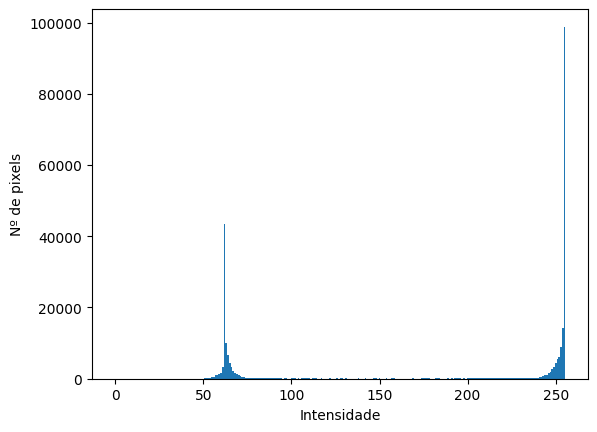

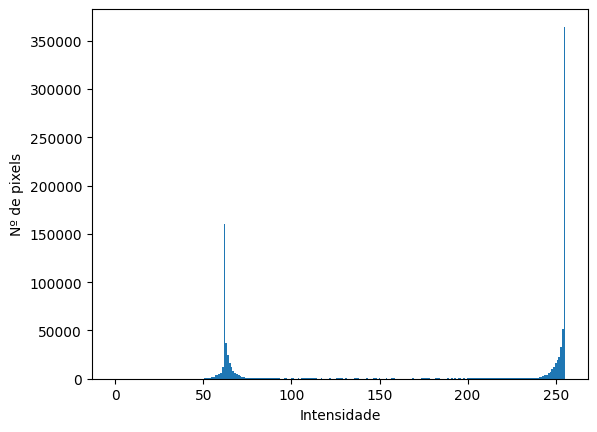

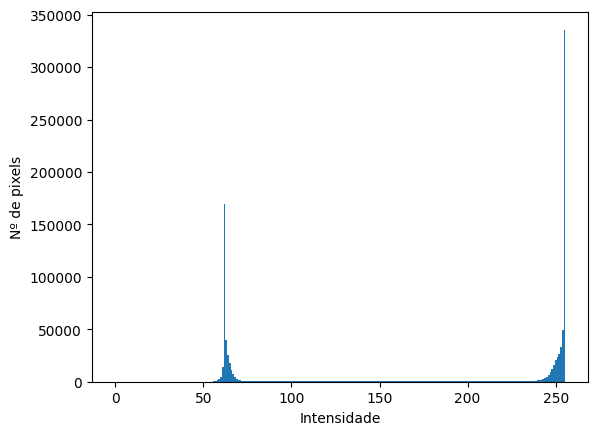

Imagem 2 ----------------------


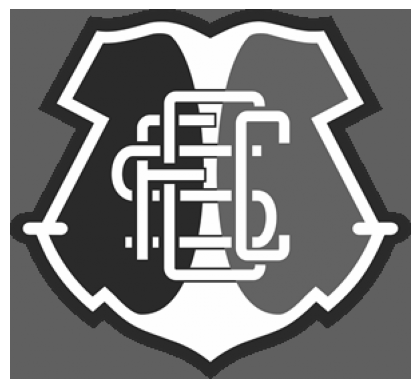

Shape (277, 300)
Redimensionada (com vizinhos) ----------------------


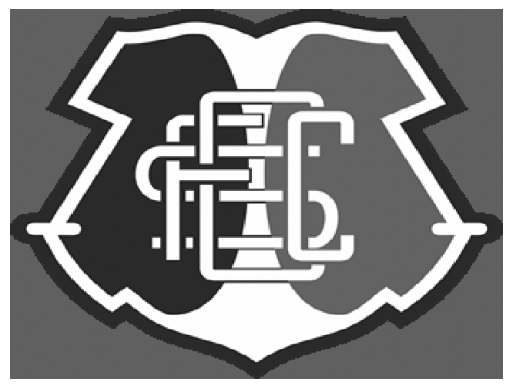

Shape (480, 640)
Redimensionada (bilinear) ----------------------


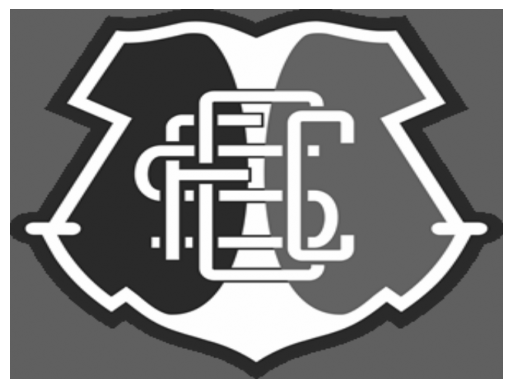

Shape (480, 640)
----------------------
HIstogramas


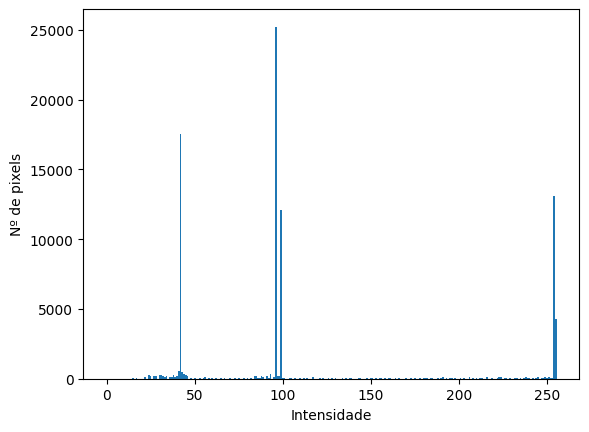

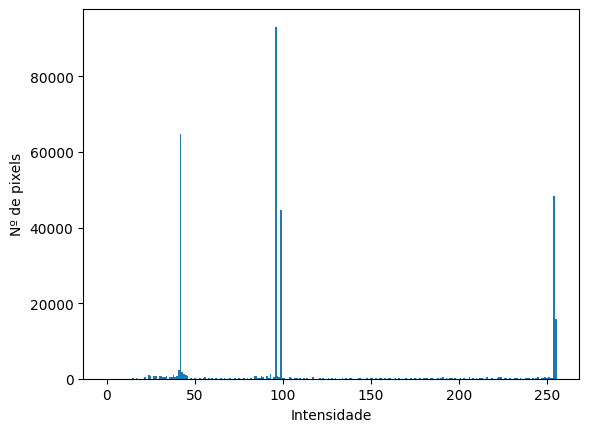

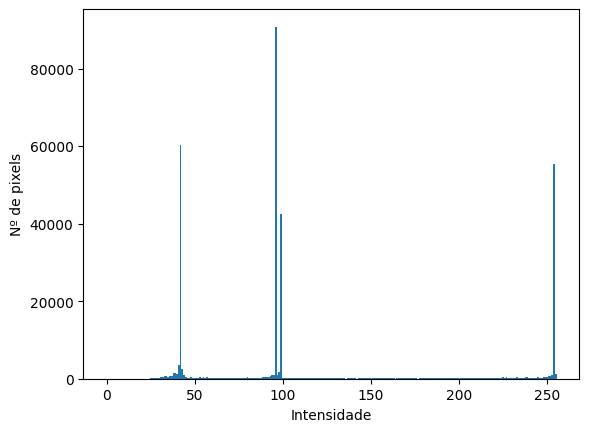

Imagem 3 ----------------------


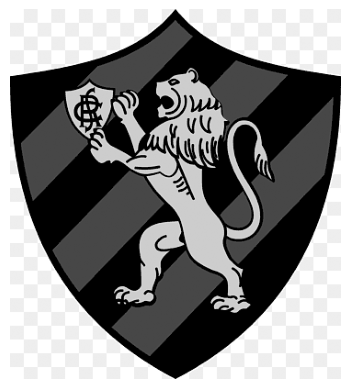

Shape (403, 360)
Redimensionada (com vizinhos) ----------------------


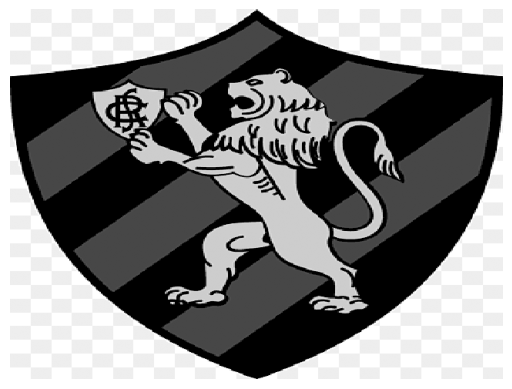

Shape (480, 640)
Redimensionada (bilinear) ----------------------


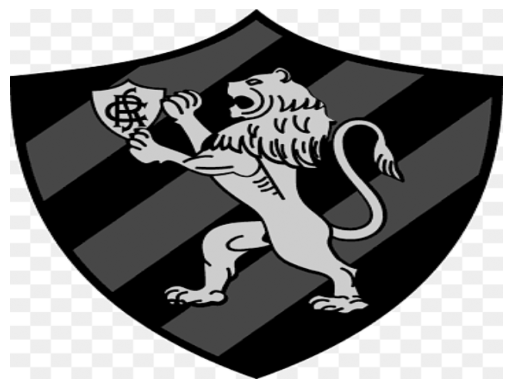

Shape (480, 640)
----------------------
HIstogramas


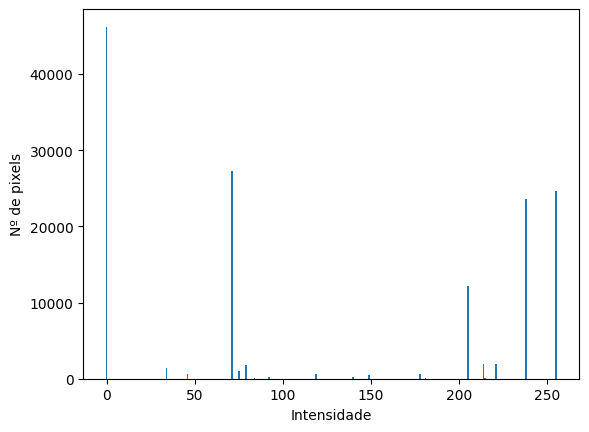

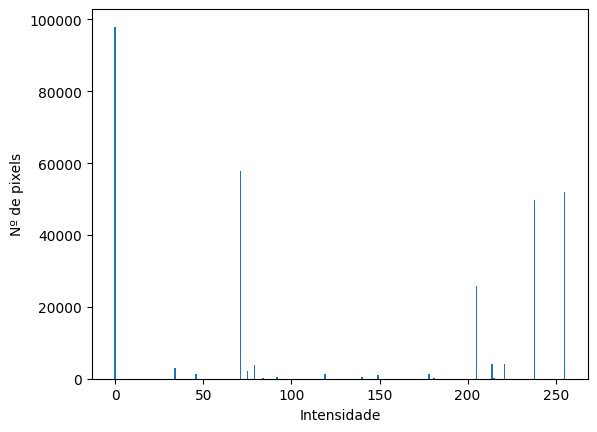

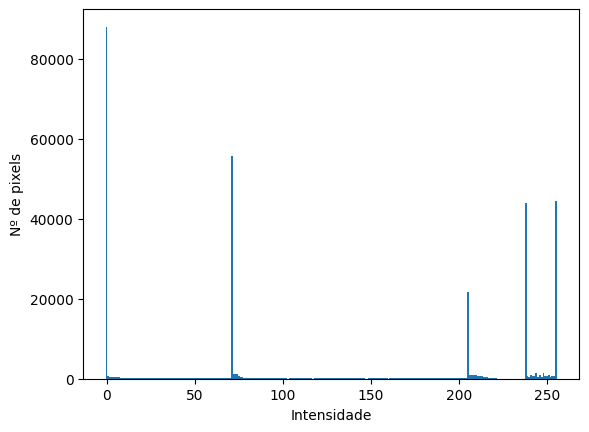

Questão 2 — Composição HD ----------------------


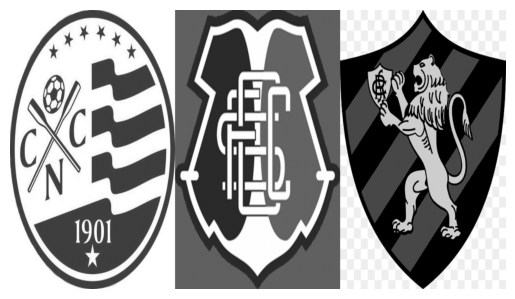

Shape (720, 1280)


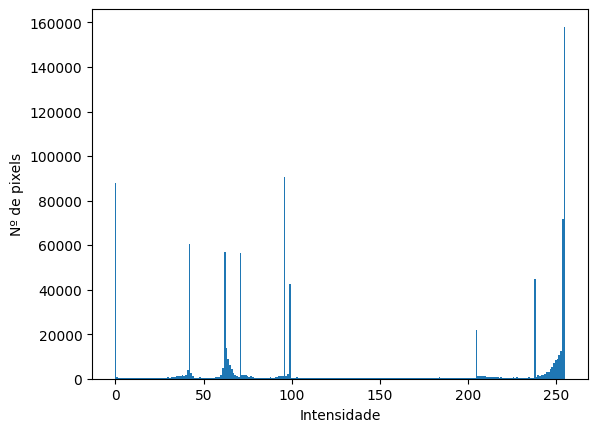

20 arquivos no zip:
img_01_cinza.png
img_01_cinza_redimensionada_bilinear.png
img_01_cinza_redimensionada_vizinhos.png
img_01_histograma_original.png
img_01_histograma_redimensionada_bilinear.png
img_01_histograma_redimensionada_vizinhos.png
img_02_cinza.png
img_02_cinza_redimensionada_bilinear.png
img_02_cinza_redimensionada_vizinhos.png
img_02_histograma_original.png
img_02_histograma_redimensionada_bilinear.png
img_02_histograma_redimensionada_vizinhos.png
img_03_cinza.png
img_03_cinza_redimensionada_bilinear.png
img_03_cinza_redimensionada_vizinhos.png
img_03_histograma_original.png
img_03_histograma_redimensionada_bilinear.png
img_03_histograma_redimensionada_vizinhos.png
img_lado_a_lado_cinza.png
img_lado_a_lado_histograma.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Auxiliar, apenas para baixar os arquivos gerados
import glob
import zipfile
from google.colab import files

# from google.colab import files
# files.upload()

# Função auxiliar apenas para baixar arquivos ao final da execução
def baixar_arquivos_gerados(total_esperado=20):
    arquivos = sorted(glob.glob("img_*_cinza*.png") + glob.glob("img_*_histograma*.png"))

    with zipfile.ZipFile("atividade_01_resultados.zip", "w") as zip_file:
        for arquivo in arquivos:
            zip_file.write(arquivo)

    print(f"{len(arquivos)} arquivos no zip:")
    print(*arquivos, sep="\n")
    assert len(arquivos) == total_esperado, "faltou arquivo! confere os savefig acima"

    files.download("atividade_01_resultados.zip")

def converter_imagem_para_tons_de_cinza(img_rgb):
    if img_rgb.ndim == 2:
      return img_rgb

    r = img_rgb[:, :, 0].astype(np.float64)
    g = img_rgb[:, :, 1].astype(np.float64)
    b = img_rgb[:, :, 2].astype(np.float64)
    cinza = 0.299 * r + 0.587 * g + 0.114 * b
    return np.round(cinza).astype(np.uint8)

def gerar_histograma(img):
    return np.bincount(img.flatten(), minlength=256)

def redimensionar_imagem(img, altura_nova, largura_nova):
    altura, largura = img.shape
    ys = np.arange(altura_nova) * altura // altura_nova
    xs = np.arange(largura_nova) * largura // largura_nova
    return img[ys][:, xs]

def redimensionar_imagem_bilinear(img, alt_nova, larg_nova):
    alt, larg = img.shape
    img = img.astype(np.float64)

    y_orig = np.arange(alt_nova) * (alt - 1) / (alt_nova - 1)
    x_orig = np.arange(larg_nova) * (larg - 1) / (larg_nova - 1)

    # cantos superiores esquerdos
    y0 = y_orig.astype(int)
    x0 = x_orig.astype(int)
    # vizinhos com proteção de borda
    y1 = np.minimum(y0 + 1, alt - 1)
    x1 = np.minimum(x0 + 1, larg - 1)

    dy = (y_orig - y0)[:, None]
    dx = x_orig - x0

    topo = img[y0[:, None], x0] * (1 - dx) + img[y0[:, None], x1] * dx
    base = img[y1[:, None], x0] * (1 - dx) + img[y1[:, None], x1] * dx
    saida = topo * (1 - dy) + base * dy
    return saida.astype(np.uint8)

def criar_imagens_lado_a_lado(imgs, altura=720, largura_total=1280):
    largura_base = largura_total // len(imgs)
    larguras = [largura_base] * len(imgs)

    # ajuste na funcao para que a ultima imagem tome o resto da imagem
    larguras[-1] += largura_total - largura_base * len(imgs)

    partes = [redimensionar_imagem_bilinear(img, altura, largura)
              for img, largura in zip(imgs, larguras)]
    return np.hstack(partes)

img_01 = converter_imagem_para_tons_de_cinza(np.array(Image.open("/content/img_1.png").convert("RGBA")))
img_02 = converter_imagem_para_tons_de_cinza(np.array(Image.open("/content/img_2.png").convert("RGBA")))
img_03 = converter_imagem_para_tons_de_cinza(np.array(Image.open("/content/img_3.png").convert("RGBA")))

print("Imagem 1 ----------------------")

plt.imshow(img_01, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_01).save("img_01_cinza.png")
plt.show()

print("Shape", img_01.shape)
print("Redimensionada (com vizinhos) ----------------------")

img_01_redimensionada = redimensionar_imagem(img_01, 720, 1280)
plt.imshow(img_01_redimensionada, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_01_redimensionada).save("img_01_cinza_redimensionada_vizinhos.png")
plt.show()

print("Shape", img_01_redimensionada.shape)
print("Redimensionada (bilinear) ----------------------")

img_01_redimensionada_biliniear = redimensionar_imagem_bilinear(img_01, 720, 1280)
plt.imshow(img_01_redimensionada_biliniear, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_01_redimensionada_biliniear).save("img_01_cinza_redimensionada_bilinear.png")
plt.show()

print("Shape", img_01_redimensionada_biliniear.shape)
print("----------------------")
print("HIstogramas")

plt.bar(range(256), gerar_histograma(img_01), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_01_histograma_original.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_01_redimensionada), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_01_histograma_redimensionada_vizinhos.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_01_redimensionada_biliniear), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_01_histograma_redimensionada_bilinear.png", dpi=150, bbox_inches="tight")
plt.show()

print("Imagem 2 ----------------------")

plt.imshow(img_02, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_02).save("img_02_cinza.png")
plt.show()

print("Shape", img_02.shape)
print("Redimensionada (com vizinhos) ----------------------")

img_02_redimensionada = redimensionar_imagem(img_02, 480, 640)
plt.imshow(img_02_redimensionada, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_02_redimensionada).save("img_02_cinza_redimensionada_vizinhos.png")
plt.show()

print("Shape", img_02_redimensionada.shape)
print("Redimensionada (bilinear) ----------------------")

img_02_redimensionada_biliniear = redimensionar_imagem_bilinear(img_02, 480, 640)
plt.imshow(img_02_redimensionada_biliniear, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_02_redimensionada_biliniear).save("img_02_cinza_redimensionada_bilinear.png")
plt.show()

print("Shape", img_02_redimensionada_biliniear.shape)
print("----------------------")
print("HIstogramas")

plt.bar(range(256), gerar_histograma(img_02), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_02_histograma_original.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_02_redimensionada), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_02_histograma_redimensionada_vizinhos.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_02_redimensionada_biliniear), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_02_histograma_redimensionada_bilinear.png", dpi=150, bbox_inches="tight")
plt.show()

print("Imagem 3 ----------------------")

plt.imshow(img_03, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_03).save("img_03_cinza.png")
plt.show()

print("Shape", img_03.shape)
print("Redimensionada (com vizinhos) ----------------------")

img_03_redimensionada = redimensionar_imagem(img_03, 480, 640)
plt.imshow(img_03_redimensionada, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_03_redimensionada).save("img_03_cinza_redimensionada_vizinhos.png")
plt.show()

print("Shape", img_03_redimensionada.shape)
print("Redimensionada (bilinear) ----------------------")

img_03_redimensionada_biliniear = redimensionar_imagem_bilinear(img_03, 480, 640)
plt.imshow(img_03_redimensionada_biliniear, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_03_redimensionada_biliniear).save("img_03_cinza_redimensionada_bilinear.png")
plt.show()

print("Shape", img_03_redimensionada_biliniear.shape)
print("----------------------")
print("HIstogramas")

plt.bar(range(256), gerar_histograma(img_03), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_03_histograma_original.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_03_redimensionada), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_03_histograma_redimensionada_vizinhos.png", dpi=150, bbox_inches="tight")
plt.show()

plt.bar(range(256), gerar_histograma(img_03_redimensionada_biliniear), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_03_histograma_redimensionada_bilinear.png", dpi=150, bbox_inches="tight")
plt.show()

print("Questão 2 — Composição HD ----------------------")

img_lado_a_lado = criar_imagens_lado_a_lado([img_01, img_02, img_03])

plt.imshow(img_lado_a_lado, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
Image.fromarray(img_lado_a_lado).save("img_lado_a_lado_cinza.png")
plt.show()

print("Shape", img_lado_a_lado.shape)

plt.bar(range(256), gerar_histograma(img_lado_a_lado), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.savefig("img_lado_a_lado_histograma.png", dpi=150, bbox_inches="tight")
plt.show()

baixar_arquivos_gerados()
